# Marketing Campaign Analysis

## Project Overview

This end-to-end marketing analytics project examines customer demographics, product spending, purchasing channels and campaign responses. The goal is to identify valuable customer groups, understand the factors associated with campaign acceptance and recommend practical ways to improve marketing effectiveness.

## Business Problem

A retail company has completed several marketing campaigns but needs a consolidated analytical solution to answer five management questions:

1. Which customer segments have the highest campaign response rates?
2. How does spending vary across age, income, education, relationship status and country?
3. Which purchase channels are preferred by high-value customers?
4. Are there under-served customers with high engagement but low spending and response?
5. What are the characteristics of ideal customers for future campaigns?

## Project Objectives

- Clean and validate the customer-level data.
- Engineer meaningful marketing and customer-value features.
- Perform univariate, bivariate and multivariate analysis.
- Create rule-based customer segments.
- Generate Power BI-ready analytical tables.
- Support MySQL analysis through a clean exported dataset.
- Provide evidence-based business insights and recommendations.

## Technologies

Python, Pandas, NumPy, Matplotlib, Seaborn, MySQL, MySQL Workbench and Power BI.

## Author

**Ameena Juhi**


# Step 1: Import Required Libraries

## Objective

Import the libraries used for data loading, cleaning, feature engineering, numerical analysis, visualisation and file handling.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")


Libraries imported successfully.


# Step 2: Load the Datasets

## Objective

Locate and load the raw marketing dataset and its data dictionary. The path logic works when the notebook is opened from either the project folder or the `Notebook` folder.


In [2]:
current_folder = Path.cwd()

if current_folder.name.lower() == "notebook":
    project_folder = current_folder.parent
else:
    project_folder = current_folder

dataset_folder = project_folder / "Dataset"
data_file = dataset_folder / "marketing_campaign_data.csv"
dictionary_file = dataset_folder / "marketing_data_dictionary.csv"

print("Project folder:", project_folder)
print("Marketing dataset found:", data_file.exists())
print("Data dictionary found:", dictionary_file.exists())


Project folder: c:\Users\RAmeenaJuhi\Marketing_Campaign_Analysis
Marketing dataset found: True
Data dictionary found: True


In [3]:
marketing_df = pd.read_csv(data_file)
dictionary_df = pd.read_csv(dictionary_file, encoding="utf-8-sig")

print("Marketing dataset shape:", marketing_df.shape)
print("Data dictionary shape:", dictionary_df.shape)


Marketing dataset shape: (56000, 28)
Data dictionary shape: (28, 2)


## 2.1 Preview the Marketing Dataset

Each row represents one customer. The original fields describe demographics, enrollment, recent activity, product spending, purchase channels, campaign acceptance, complaints and country.


In [4]:
marketing_df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,342199,1985,Graduation,Together,"59,011.70",1,0,2012-11-17,3,0,2,45,6,0,16,3,2,5,3,4,0,0,0,0,0,0,0,Spain
1,8075450,1975,Master,Single,"1,730.00",1,1,2013-04-10,96,0,0,19,1,19,0,1,1,0,2,3,0,0,0,0,0,0,0,Spain
2,13664263,1978,Graduation,Married,"98,584.60",0,0,2014-01-11,99,920,0,339,0,115,138,3,2,1,6,3,0,0,0,0,0,0,0,Australia
3,16164787,1976,Graduation,Married,"74,031.50",1,0,2014-06-18,47,265,0,130,7,1,75,1,4,0,11,4,0,0,0,0,0,0,0,Spain
4,15815139,1981,Graduation,Divorced,"52,784.20",1,1,2014-05-20,0,30,3,55,242,0,0,1,3,2,3,6,0,0,0,0,0,0,0,Canada


## 2.2 Review the Data Dictionary


In [5]:
dictionary_df


,Field,Description
0,ID,Customer's unique identifier
1,Year_Birth,Customer's birth year
2,Education,Customer's education level
3,Marital_Status,Customer's marital status
4,Income,Customer's yearly household income
5,Kidhome,Number of children in customer's household
6,Teenhome,Number of teenagers in customer's household
7,Dt_Customer,Date of customer's enrollment with the company
8,Recency,Number of days since customer's last purchase
9,MntWines,Amount spent on wine in the last 2 years


### Initial Observation

- The marketing dataset should contain 28 original columns.
- `ID` is the customer identifier.
- `Dt_Customer` is the enrollment date.
- `Mnt*` columns represent spending by product.
- `Num*Purchases` columns represent purchase activity.
- `AcceptedCmp1` to `AcceptedCmp5` and `Response` are campaign indicators.


# Step 3: Data Understanding and Quality Assessment

## Objective

Examine the dataset structure, data types, missing values, duplicates, category consistency, date validity, binary values and numerical ranges before cleaning.


## 3.1 Dataset Dimensions and Column Names


In [6]:
print("Number of customers:", marketing_df.shape[0])
print("Number of original columns:", marketing_df.shape[1])

for position, column_name in enumerate(marketing_df.columns, start=1):
    print(f"{position}. {column_name}")


Number of customers: 56000
Number of original columns: 28
1. ID
2. Year_Birth
3. Education
4. Marital_Status
5. Income
6. Kidhome
7. Teenhome
8. Dt_Customer
9. Recency
10. MntWines
11. MntFruits
12. MntMeatProducts
13. MntFishProducts
14. MntSweetProducts
15. MntGoldProds
16. NumDealsPurchases
17. NumWebPurchases
18. NumCatalogPurchases
19. NumStorePurchases
20. NumWebVisitsMonth
21. AcceptedCmp3
22. AcceptedCmp4
23. AcceptedCmp5
24. AcceptedCmp1
25. AcceptedCmp2
26. Response
27. Complain
28. Country


## 3.2 Data Types and Non-Null Counts


In [7]:
marketing_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   56000 non-null  int64  
 1   Year_Birth           56000 non-null  int64  
 2   Education            56000 non-null  str    
 3   Marital_Status       56000 non-null  str    
 4   Income               56000 non-null  float64
 5   Kidhome              56000 non-null  int64  
 6   Teenhome             56000 non-null  int64  
 7   Dt_Customer          56000 non-null  str    
 8   Recency              56000 non-null  int64  
 9   MntWines             56000 non-null  int64  
 10  MntFruits            56000 non-null  int64  
 11  MntMeatProducts      56000 non-null  int64  
 12  MntFishProducts      56000 non-null  int64  
 13  MntSweetProducts     56000 non-null  int64  
 14  MntGoldProds         56000 non-null  int64  
 15  NumDealsPurchases    56000 non-null  int64  
 1

## 3.3 High-Level Data Quality Summary


In [8]:
quality_summary = pd.DataFrame({
    "Quality_Check": [
        "Total Rows", "Total Columns", "Missing Values",
        "Duplicate Rows", "Duplicate Customer IDs"
    ],
    "Result": [
        marketing_df.shape[0],
        marketing_df.shape[1],
        marketing_df.isna().sum().sum(),
        marketing_df.duplicated().sum(),
        marketing_df["ID"].duplicated().sum()
    ]
})

quality_summary


,Quality_Check,Result
0,Total Rows,56000
1,Total Columns,28
2,Missing Values,0
3,Duplicate Rows,0
4,Duplicate Customer IDs,0


### 3.3.1 Reusable Dataset Validation Function

The following reusable function summarizes the dataset dimensions, duplicate records, missing values, and customer-ID uniqueness. It improves code reusability and provides a consistent quality check.

In [9]:
def validate_dataset(dataframe, id_column="ID"):
    """Return the main dataset-quality validation results."""
    return {
        "rows": len(dataframe),
        "columns": dataframe.shape[1],
        "duplicate_rows": int(dataframe.duplicated().sum()),
        "missing_values": int(dataframe.isna().sum().sum()),
        "unique_ids": int(dataframe[id_column].nunique())
    }


validation_results = validate_dataset(marketing_df)
validation_results

{'rows': 56000,
 'columns': 28,
 'duplicate_rows': 0,
 'missing_values': 0,
 'unique_ids': 56000}

## 3.4 Missing Values by Column


In [10]:
missing_summary = pd.DataFrame({
    "Column": marketing_df.columns,
    "Missing_Count": marketing_df.isna().sum().values,
    "Missing_Percentage": (marketing_df.isna().mean().values * 100).round(2)
})

missing_summary.sort_values("Missing_Count", ascending=False)


,Column,Missing_Count,Missing_Percentage
0,ID,0,0.00
1,Year_Birth,0,0.00
2,Education,0,0.00
3,Marital_Status,0,0.00
4,Income,0,0.00
5,Kidhome,0,0.00
6,Teenhome,0,0.00
7,Dt_Customer,0,0.00
8,Recency,0,0.00
9,MntWines,0,0.00


## 3.5 Unique Customer ID Validation


In [11]:
print("Total records:", len(marketing_df))
print("Unique customer IDs:", marketing_df["ID"].nunique())
print("Duplicate customer IDs:", marketing_df["ID"].duplicated().sum())


Total records: 56000
Unique customer IDs: 56000
Duplicate customer IDs: 0


## 3.6 Categorical Value Assessment


In [12]:
categorical_columns = ["Education", "Marital_Status", "Country"]

for column in categorical_columns:
    print(f"\n{column} values:")
    print(marketing_df[column].value_counts(dropna=False))



Education values:
Education
Graduation    22741
PhD           12581
Master        10530
2n Cycle       5966
Basic          4182
Name: count, dtype: int64

Marital_Status values:
Marital_Status
Together    17703
Married     13686
Single      12238
Divorced     6459
Widow        3540
Alone         911
Absurd        733
YOLO          730
Name: count, dtype: int64

Country values:
Country
Spain           16703
Canada          10746
Saudi Arabia     8422
Australia        5677
India            4814
Germany          4432
USA              4331
Mexico            875
Name: count, dtype: int64


## 3.7 Date Validation


In [13]:
validated_dates = pd.to_datetime(marketing_df["Dt_Customer"], errors="coerce")

print("Earliest enrollment date:", validated_dates.min())
print("Latest enrollment date:", validated_dates.max())
print("Invalid enrollment dates:", validated_dates.isna().sum())


Earliest enrollment date: 2012-07-30 00:00:00
Latest enrollment date: 2014-06-29 00:00:00
Invalid enrollment dates: 0


## 3.8 Binary Column Validation


In [14]:
binary_columns = [
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
    "AcceptedCmp4", "AcceptedCmp5", "Response", "Complain"
]

for column in binary_columns:
    print(f"{column}: {sorted(marketing_df[column].dropna().unique())}")


AcceptedCmp1: [np.int64(0), np.int64(1)]
AcceptedCmp2: [np.int64(0), np.int64(1)]
AcceptedCmp3: [np.int64(0), np.int64(1)]
AcceptedCmp4: [np.int64(0), np.int64(1)]
AcceptedCmp5: [np.int64(0), np.int64(1)]
Response: [np.int64(0), np.int64(1)]
Complain: [np.int64(0), np.int64(1)]


## 3.9 Numerical Range and Negative Value Assessment


In [15]:
numeric_columns = marketing_df.select_dtypes(include=np.number).columns

range_summary = pd.DataFrame({
    "Minimum": marketing_df[numeric_columns].min(),
    "Maximum": marketing_df[numeric_columns].max(),
    "Negative_Count": [(marketing_df[column] < 0).sum() for column in numeric_columns]
})

range_summary


,Minimum,Maximum,Negative_Count
ID,36.00,"16,777,158.00",0
Year_Birth,"1,936.00","1,996.00",0
Income,"1,730.00","258,027.50",0
Kidhome,0.00,2.00,0
Teenhome,0.00,2.00,0
Recency,0.00,99.00,0
MntWines,0.00,"1,493.00",0
MntFruits,0.00,199.00,0
MntMeatProducts,0.00,"1,341.00",0
MntFishProducts,0.00,259.00,0


### Data Quality Conclusion

The checks above establish whether missing values, duplicates, invalid categories, invalid dates, binary-value problems or negative business values require treatment. Income and spending extremes are assessed separately because valid premium customers must not be removed automatically.


# Step 4: Data Cleaning

## Objective

Create a reliable analytical dataset while preserving the original dataframe. Standardise data types and categories, remove duplicates if found, validate ranges and flag income outliers instead of deleting potentially valuable customers.


## 4.1 Preserve the Raw Dataset


In [16]:
cleaned_df = marketing_df.copy()

print("Raw shape:", marketing_df.shape)
print("Working copy shape:", cleaned_df.shape)


Raw shape: (56000, 28)
Working copy shape: (56000, 28)


## 4.2 Standardise Column Names and Text Values


In [17]:
cleaned_df.columns = cleaned_df.columns.str.strip()

text_columns = ["Education", "Marital_Status", "Country"]
for column in text_columns:
    cleaned_df[column] = cleaned_df[column].astype("string").str.strip()

print("Column names and text values standardised.")


Column names and text values standardised.


## 4.3 Remove Duplicate Records


In [18]:
rows_before = len(cleaned_df)
cleaned_df = cleaned_df.drop_duplicates().copy()
rows_after = len(cleaned_df)

print("Rows before:", rows_before)
print("Rows after:", rows_after)
print("Duplicates removed:", rows_before - rows_after)


Rows before: 56000
Rows after: 56000
Duplicates removed: 0


## 4.4 Convert the Enrollment Date


In [19]:
cleaned_df["Dt_Customer"] = pd.to_datetime(
    cleaned_df["Dt_Customer"], errors="coerce"
)

print("Dt_Customer type:", cleaned_df["Dt_Customer"].dtype)
print("Invalid dates:", cleaned_df["Dt_Customer"].isna().sum())


Dt_Customer type: datetime64[us]
Invalid dates: 0


## 4.5 Standardise Education and Relationship Categories


In [20]:
cleaned_df["Education_Group"] = cleaned_df["Education"].replace({
    "2n Cycle": "2nd Cycle"
})

cleaned_df["Relationship_Status"] = cleaned_df["Marital_Status"].replace({
    "Alone": "Single",
    "YOLO": "Single",
    "Absurd": "Other"
})

print("Education groups:", sorted(cleaned_df["Education_Group"].unique()))
print("Relationship groups:", sorted(cleaned_df["Relationship_Status"].unique()))


Education groups: ['2nd Cycle', 'Basic', 'Graduation', 'Master', 'PhD']
Relationship groups: ['Divorced', 'Married', 'Other', 'Single', 'Together', 'Widow']


## 4.6 Income Outlier Assessment

The IQR method is used to flag unusual income values. Records are retained because high-income customers may be commercially important.


In [21]:
income_q1 = cleaned_df["Income"].quantile(0.25)
income_q3 = cleaned_df["Income"].quantile(0.75)
income_iqr = income_q3 - income_q1
income_lower_limit = income_q1 - 1.5 * income_iqr
income_upper_limit = income_q3 + 1.5 * income_iqr

cleaned_df["Income_Outlier_Flag"] = np.where(
    (cleaned_df["Income"] < income_lower_limit)
    | (cleaned_df["Income"] > income_upper_limit),
    "Outlier", "Normal"
)

print("Income lower limit:", round(income_lower_limit, 2))
print("Income upper limit:", round(income_upper_limit, 2))
print(cleaned_df["Income_Outlier_Flag"].value_counts())


Income lower limit: -59765.91
Income upper limit: 174948.59
Income_Outlier_Flag
Normal     55986
Outlier       14
Name: count, dtype: int64


## 4.7 Final Cleaning Validation


In [22]:
cleaning_validation = pd.DataFrame({
    "Validation_Check": [
        "Total Rows", "Missing Values", "Duplicate Rows",
        "Duplicate Customer IDs", "Invalid Dates"
    ],
    "Result": [
        len(cleaned_df), cleaned_df.isna().sum().sum(),
        cleaned_df.duplicated().sum(), cleaned_df["ID"].duplicated().sum(),
        cleaned_df["Dt_Customer"].isna().sum()
    ]
})

cleaning_validation


,Validation_Check,Result
0,Total Rows,56000
1,Missing Values,0
2,Duplicate Rows,0
3,Duplicate Customer IDs,0
4,Invalid Dates,0


### Data Cleaning Conclusion

The raw data remains preserved in `marketing_df`. The analytical copy has consistent column names, proper dates, standardised categories and an explicit income-outlier flag. No valid high-value customer is deleted solely because of income.


# Step 5: Feature Engineering

## Objective

Create business features that convert the original operational fields into customer-level measures suitable for segmentation, MySQL analysis and Power BI reporting.


## 5.1 Analysis Reference Date, Age and Customer Tenure


In [23]:
analysis_date = cleaned_df["Dt_Customer"].max() + pd.Timedelta(days=1)

cleaned_df["Age"] = analysis_date.year - cleaned_df["Year_Birth"]
cleaned_df["Customer_Tenure_Days"] = (
    analysis_date - cleaned_df["Dt_Customer"]
).dt.days
cleaned_df["Customer_Tenure_Months"] = (
    cleaned_df["Customer_Tenure_Days"] / 30.44
).round(1)

print("Analysis reference date:", analysis_date.date())
cleaned_df[["Year_Birth", "Age", "Dt_Customer", "Customer_Tenure_Months"]].head()


Analysis reference date: 2014-06-30


,Year_Birth,Age,Dt_Customer,Customer_Tenure_Months
0,1985,29,2012-11-17,19.40
1,1975,39,2013-04-10,14.70
2,1978,36,2014-01-11,5.60
3,1976,38,2014-06-18,0.40
4,1981,33,2014-05-20,1.30


## 5.2 Children and Family Status


In [24]:
cleaned_df["Total_Children"] = cleaned_df["Kidhome"] + cleaned_df["Teenhome"]
cleaned_df["Has_Children"] = np.where(
    cleaned_df["Total_Children"] > 0, "Yes", "No"
)

cleaned_df[["Kidhome", "Teenhome", "Total_Children", "Has_Children"]].head()


,Kidhome,Teenhome,Total_Children,Has_Children
0,1,0,1,Yes
1,1,1,2,Yes
2,0,0,0,No
3,1,0,1,Yes
4,1,1,2,Yes


## 5.3 Total Product Spending


In [25]:
product_columns = [
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds"
]

cleaned_df["Total_Spend"] = cleaned_df[product_columns].sum(axis=1)

cleaned_df[product_columns + ["Total_Spend"]].head()


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Total_Spend
0,0,2,45,6,0,16,69
1,0,0,19,1,19,0,39
2,920,0,339,0,115,138,1512
3,265,0,130,7,1,75,478
4,30,3,55,242,0,0,330


## 5.4 Total Purchases and Preferred Channel


In [26]:
channel_columns = [
    "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"
]

cleaned_df["Total_Purchases"] = cleaned_df[channel_columns].sum(axis=1)

channel_name_mapping = {
    "NumWebPurchases": "Web",
    "NumCatalogPurchases": "Catalog",
    "NumStorePurchases": "Store"
}

cleaned_df["Preferred_Channel"] = (
    cleaned_df[channel_columns].idxmax(axis=1).map(channel_name_mapping)
)
cleaned_df.loc[cleaned_df["Total_Purchases"] == 0, "Preferred_Channel"] = "No Purchase"

cleaned_df[channel_columns + ["Total_Purchases", "Preferred_Channel"]].head()


,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Total_Purchases,Preferred_Channel
0,2,5,3,10,Catalog
1,1,0,2,3,Store
2,2,1,6,9,Store
3,4,0,11,15,Store
4,3,2,3,8,Web


### Business Note

`NumDealsPurchases` is not added to `Total_Purchases` because it describes purchases made with a discount and may overlap with web, catalogue or store purchases. Keeping it separate avoids double counting.


## 5.5 Campaign Acceptance Metrics


In [27]:
historical_campaign_columns = [
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
    "AcceptedCmp4", "AcceptedCmp5"
]

cleaned_df["Historical_Accepted_Campaigns"] = cleaned_df[
    historical_campaign_columns
].sum(axis=1)

cleaned_df["Total_Accepted_Campaigns"] = (
    cleaned_df["Historical_Accepted_Campaigns"] + cleaned_df["Response"]
)

cleaned_df["Campaign_Acceptance_Rate"] = (
    cleaned_df["Total_Accepted_Campaigns"] / 6
)

cleaned_df[
    ["Historical_Accepted_Campaigns", "Response",
     "Total_Accepted_Campaigns", "Campaign_Acceptance_Rate"]
].head()


,Historical_Accepted_Campaigns,Response,Total_Accepted_Campaigns,Campaign_Acceptance_Rate
0,0,0,0,0.00
1,0,0,0,0.00
2,0,0,0,0.00
3,0,0,0,0.00
4,0,0,0,0.00


## 5.6 Age Group and Income Band


In [28]:
cleaned_df["Age_Group"] = pd.cut(
    cleaned_df["Age"],
    bins=[0, 29, 39, 49, 59, 69, np.inf],
    labels=["Under 30", "30-39", "40-49", "50-59", "60-69", "70+"],
    include_lowest=True
)

cleaned_df["Income_Band"] = pd.cut(
    cleaned_df["Income"],
    bins=[-np.inf, 30000, 50000, 75000, 100000, np.inf],
    labels=["Low", "Lower-Middle", "Middle", "High", "Premium"]
)

print(cleaned_df["Age_Group"].value_counts().sort_index())
print(cleaned_df["Income_Band"].value_counts().sort_index())


Age_Group
Under 30     8285
30-39       16487
40-49       15647
50-59        9931
60-69        4912
70+           738
Name: count, dtype: int64
Income_Band
Low             14735
Lower-Middle     8908
Middle          12575
High            12505
Premium          7277
Name: count, dtype: int64


## 5.7 Relationship Group


In [29]:
cleaned_df["Relationship_Group"] = cleaned_df["Relationship_Status"].map({
    "Married": "Partnered",
    "Together": "Partnered",
    "Single": "Not Partnered",
    "Divorced": "Not Partnered",
    "Widow": "Not Partnered",
    "Other": "Other"
}).fillna("Other")

cleaned_df["Relationship_Group"].value_counts()


Relationship_Group
Partnered        31389
Not Partnered    23878
Other              733
Name: count, dtype: int64

## 5.8 Spending, Purchase-Frequency and Customer-Value Segments


In [30]:
spend_median = cleaned_df["Total_Spend"].median()
spend_p90 = cleaned_df["Total_Spend"].quantile(0.90)
purchase_median = cleaned_df["Total_Purchases"].median()
purchase_p75 = cleaned_df["Total_Purchases"].quantile(0.75)

cleaned_df["Spending_Segment"] = np.select(
    [
        cleaned_df["Total_Spend"] >= spend_p90,
        cleaned_df["Total_Spend"] >= spend_median
    ],
    ["High Spender", "Medium Spender"],
    default="Low Spender"
)

cleaned_df["Purchase_Frequency"] = np.select(
    [
        cleaned_df["Total_Purchases"] >= purchase_p75,
        cleaned_df["Total_Purchases"] >= purchase_median
    ],
    ["Frequent", "Regular"],
    default="Occasional"
)

cleaned_df["Customer_Value_Segment"] = np.select(
    [
        (cleaned_df["Total_Spend"] >= spend_p90)
        & (cleaned_df["Total_Purchases"] >= purchase_p75),
        (cleaned_df["Total_Spend"] >= spend_median)
    ],
    ["Premium Value", "Growth Value"],
    default="Standard Value"
)

cleaned_df[["Spending_Segment", "Purchase_Frequency", "Customer_Value_Segment"]].head()


,Spending_Segment,Purchase_Frequency,Customer_Value_Segment
0,Low Spender,Occasional,Standard Value
1,Low Spender,Occasional,Standard Value
2,Medium Spender,Occasional,Growth Value
3,Medium Spender,Frequent,Growth Value
4,Low Spender,Occasional,Standard Value


## 5.9 Feature Engineering Validation


In [31]:
engineered_columns = [
    "Age", "Customer_Tenure_Days", "Customer_Tenure_Months",
    "Total_Children", "Has_Children", "Total_Spend", "Total_Purchases",
    "Preferred_Channel", "Historical_Accepted_Campaigns",
    "Total_Accepted_Campaigns", "Campaign_Acceptance_Rate",
    "Age_Group", "Income_Band", "Relationship_Group",
    "Spending_Segment", "Purchase_Frequency", "Customer_Value_Segment"
]

print("Engineered features created:", len(engineered_columns))
print("Missing values in engineered features:", cleaned_df[engineered_columns].isna().sum().sum())
cleaned_df[engineered_columns].head()


Engineered features created: 17
Missing values in engineered features: 0


,Age,Customer_Tenure_Days,Customer_Tenure_Months,Total_Children,Has_Children,Total_Spend,Total_Purchases,Preferred_Channel,Historical_Accepted_Campaigns,Total_Accepted_Campaigns,Campaign_Acceptance_Rate,Age_Group,Income_Band,Relationship_Group,Spending_Segment,Purchase_Frequency,Customer_Value_Segment
0,29,590,19.40,1,Yes,69,10,Catalog,0,0,0.00,Under 30,Middle,Partnered,Low Spender,Occasional,Standard Value
1,39,446,14.70,2,Yes,39,3,Store,0,0,0.00,30-39,Low,Not Partnered,Low Spender,Occasional,Standard Value
2,36,170,5.60,0,No,1512,9,Store,0,0,0.00,30-39,High,Partnered,Medium Spender,Occasional,Growth Value
3,38,12,0.40,1,Yes,478,15,Store,0,0,0.00,30-39,Middle,Partnered,Medium Spender,Frequent,Growth Value
4,33,41,1.30,2,Yes,330,8,Web,0,0,0.00,30-39,Middle,Not Partnered,Low Spender,Occasional,Standard Value


# Step 6: Exploratory Data Analysis (EDA)

## Objective

Answer business questions through univariate, bivariate and multivariate analysis. Each visual is selected for a specific analytical purpose.


## 6.1 Customer Age Distribution

### Business Question
What is the age profile of the customer base?

### Reason for the Visual
A histogram shows both the frequency and shape of a continuous variable.


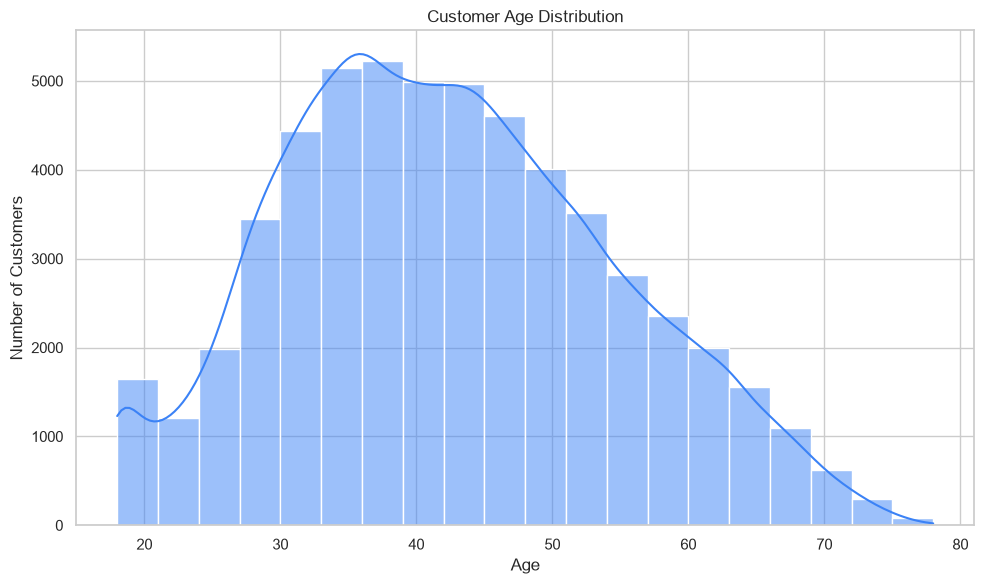

count   56,000.00
mean        42.33
std         12.21
min         18.00
25%         33.00
50%         41.00
75%         51.00
max         78.00
Name: Age, dtype: float64

In [32]:
sns.histplot(data=cleaned_df, x="Age", bins=20, kde=True, color="#3B82F6")
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

cleaned_df["Age"].describe()


## 6.2 Income Distribution

### Business Question
How is household income distributed, and are extreme values present?

### Reason for the Visual
A box plot clearly displays the median, spread and potential outliers.


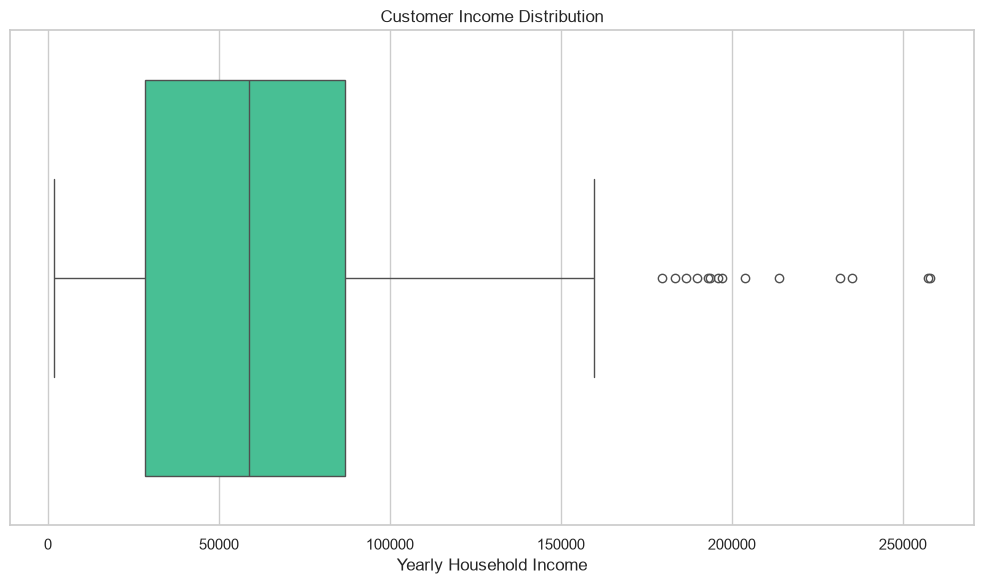

In [33]:
sns.boxplot(data=cleaned_df, x="Income", color="#34D399")
plt.title("Customer Income Distribution")
plt.xlabel("Yearly Household Income")
plt.tight_layout()
plt.show()


## 6.3 Total Spending Distribution

### Business Question
How much do customers spend across all product categories?

### Reason for the Visual
A histogram reveals spending concentration and skewness.


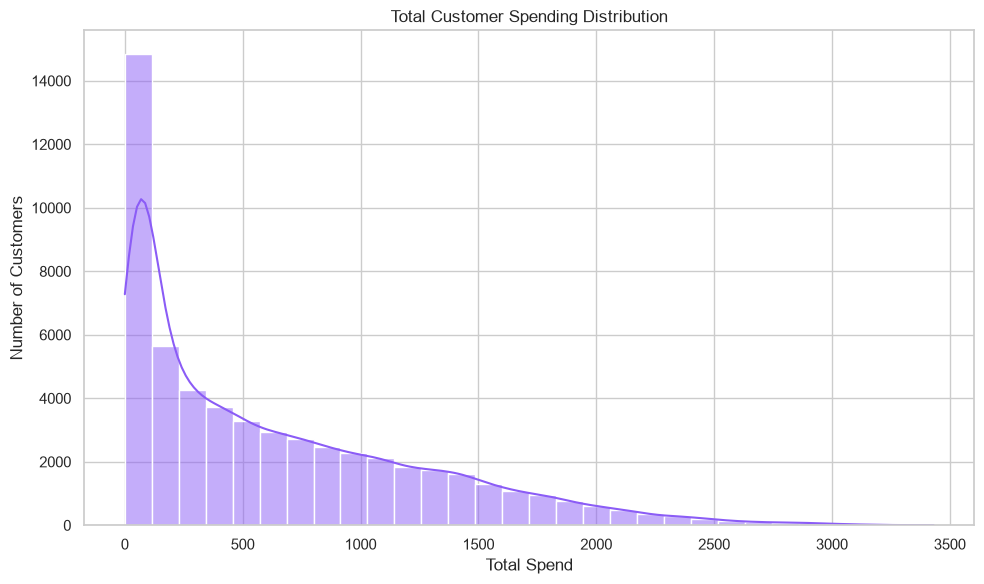

In [34]:
sns.histplot(data=cleaned_df, x="Total_Spend", bins=30, kde=True, color="#8B5CF6")
plt.title("Total Customer Spending Distribution")
plt.xlabel("Total Spend")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


## 6.4 Customers and Response Rate by Country

### Business Question
Which countries contain the largest customer bases, and which respond most effectively?

### Reason for the Visual
Horizontal bars support clear comparison across country categories.


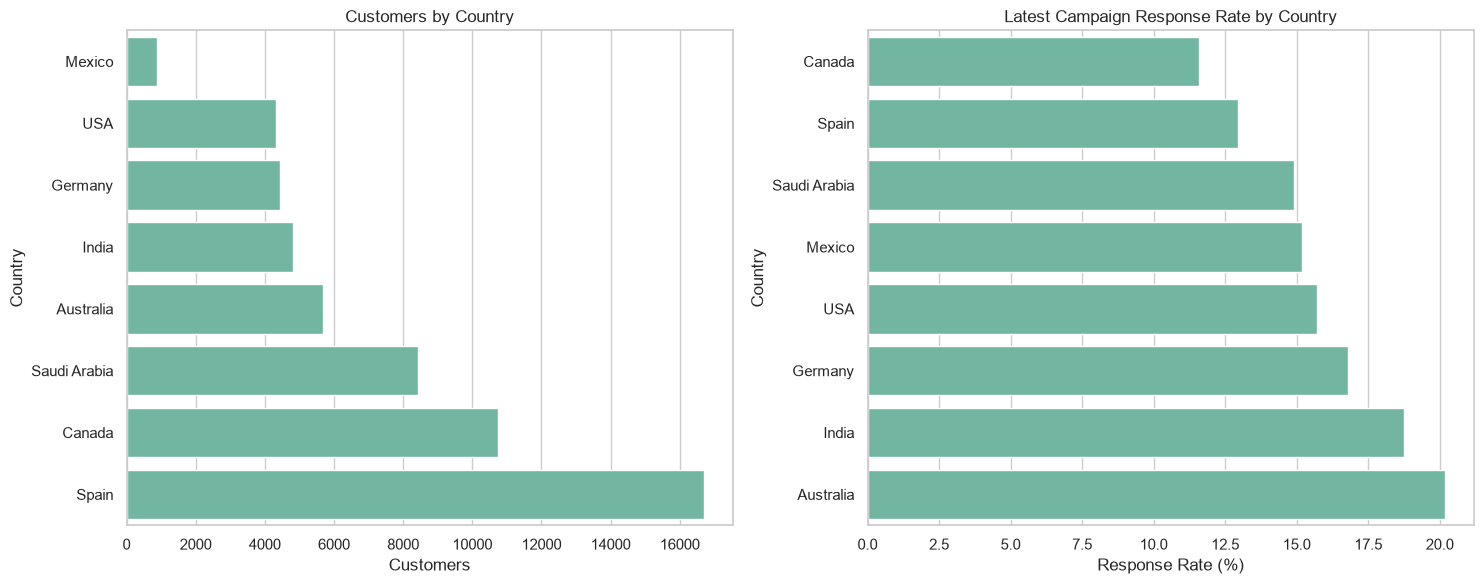

,Country,Customers,Response_Rate,Average_Spend
0,Australia,5677,20.19,827.38
3,India,4814,18.76,723.85
2,Germany,4432,16.81,707.24
7,USA,4331,15.70,663.88
4,Mexico,875,15.20,634.14
5,Saudi Arabia,8422,14.90,654.57
6,Spain,16703,12.93,557.37
1,Canada,10746,11.57,585.32


In [35]:
country_summary = cleaned_df.groupby("Country", observed=True).agg(
    Customers=("ID", "nunique"),
    Response_Rate=("Response", "mean"),
    Average_Spend=("Total_Spend", "mean")
).reset_index()
country_summary["Response_Rate"] *= 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=country_summary.sort_values("Customers"), x="Customers", y="Country", ax=axes[0])
axes[0].set_title("Customers by Country")
sns.barplot(data=country_summary.sort_values("Response_Rate"), x="Response_Rate", y="Country", ax=axes[1])
axes[1].set_title("Latest Campaign Response Rate by Country")
axes[1].set_xlabel("Response Rate (%)")
plt.tight_layout()
plt.show()

country_summary.sort_values("Response_Rate", ascending=False)


## 6.5 Average Spending by Education and Relationship Group

### Business Question
How does customer value differ across education and household relationship groups?

### Reason for the Visual
Bar charts compare average spending across discrete demographic categories.


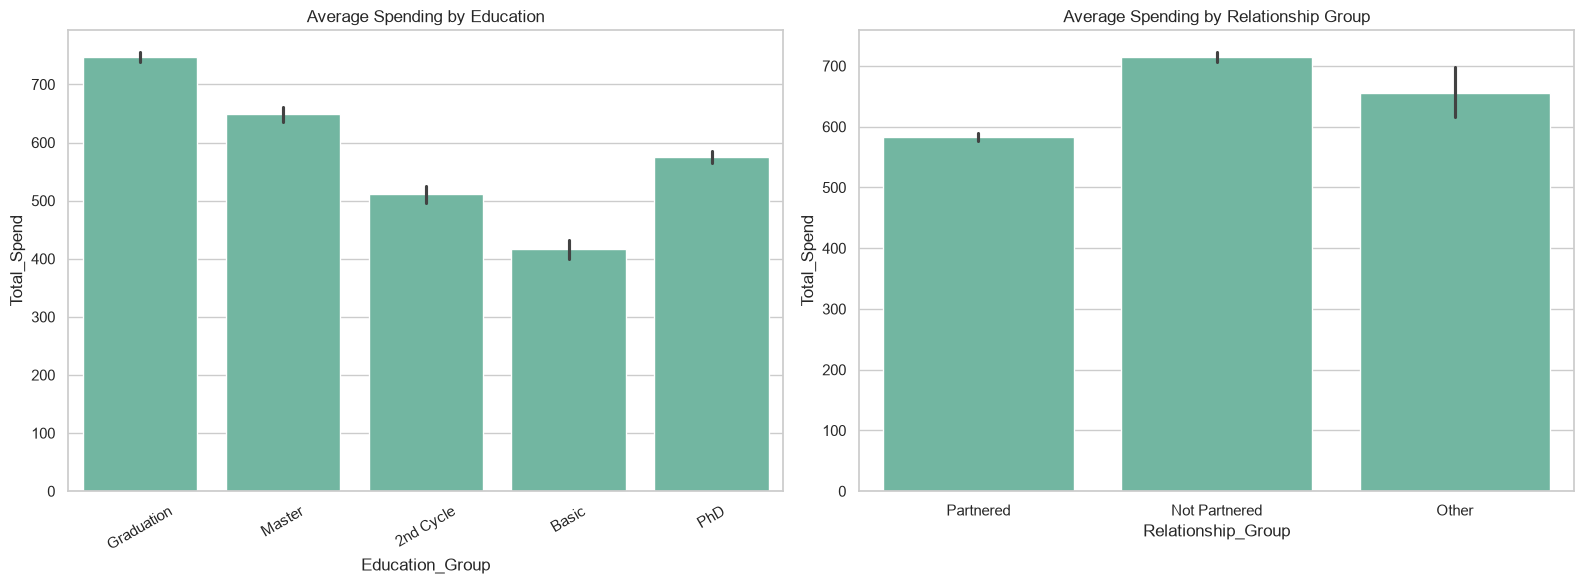

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=cleaned_df, x="Education_Group", y="Total_Spend", estimator="mean", ax=axes[0])
axes[0].set_title("Average Spending by Education")
axes[0].tick_params(axis="x", rotation=30)
sns.barplot(data=cleaned_df, x="Relationship_Group", y="Total_Spend", estimator="mean", ax=axes[1])
axes[1].set_title("Average Spending by Relationship Group")
plt.tight_layout()
plt.show()


## 6.6 Product Category Performance

### Business Question
Which product categories generate the greatest customer spending?

### Reason for the Visual
A sorted horizontal bar chart makes product performance easy to rank.


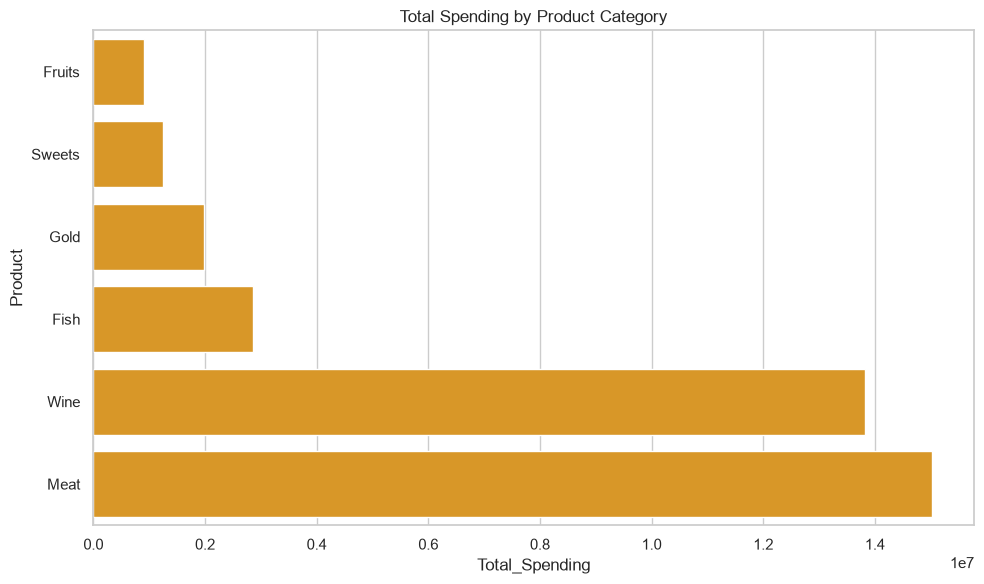

,Product,Total_Spending
5,Meat,15024465
4,Wine,13830963
3,Fish,2861473
2,Gold,1981595
1,Sweets,1255691
0,Fruits,904549


In [37]:
product_summary = cleaned_df[product_columns].sum().sort_values().reset_index()
product_summary.columns = ["Product", "Total_Spending"]
product_summary["Product"] = product_summary["Product"].replace({
    "MntWines": "Wine", "MntFruits": "Fruits", "MntMeatProducts": "Meat",
    "MntFishProducts": "Fish", "MntSweetProducts": "Sweets", "MntGoldProds": "Gold"
})

sns.barplot(data=product_summary, x="Total_Spending", y="Product", color="#F59E0B")
plt.title("Total Spending by Product Category")
plt.tight_layout()
plt.show()

product_summary.sort_values("Total_Spending", ascending=False)


## 6.7 Purchase Channel Performance

### Business Question
Which purchase channels are used most frequently?

### Reason for the Visual
A column chart provides a direct volume comparison across channels.


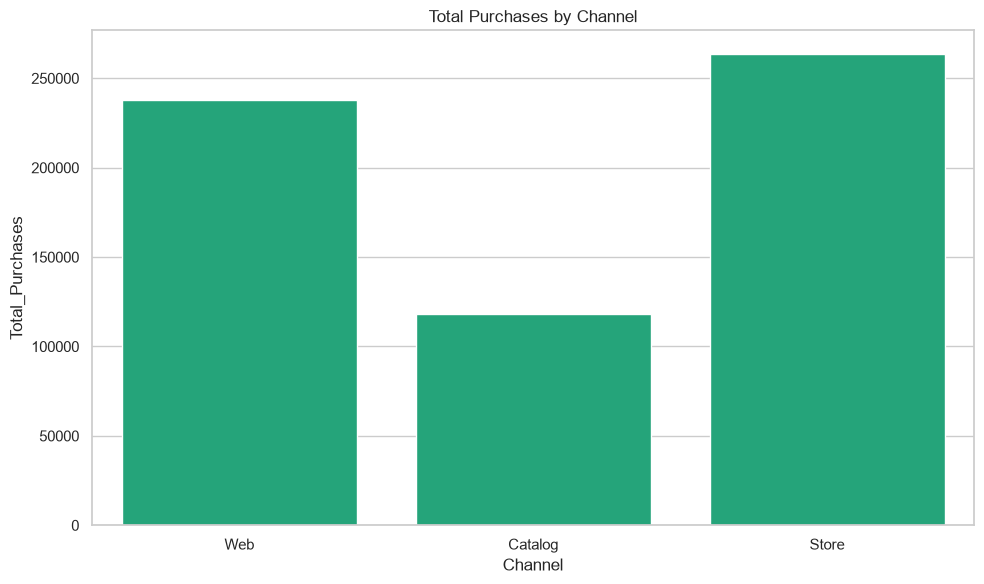

,Channel,Total_Purchases
2,Store,263559
0,Web,237938
1,Catalog,118202


In [38]:
channel_summary = cleaned_df[channel_columns].sum().reset_index()
channel_summary.columns = ["Channel", "Total_Purchases"]
channel_summary["Channel"] = channel_summary["Channel"].map(channel_name_mapping)

sns.barplot(data=channel_summary, x="Channel", y="Total_Purchases", color="#10B981")
plt.title("Total Purchases by Channel")
plt.tight_layout()
plt.show()

channel_summary.sort_values("Total_Purchases", ascending=False)


## 6.8 Campaign Acceptance Performance

### Business Question
Which marketing campaign achieved the highest acceptance rate?

### Reason for the Visual
A sorted bar chart ranks the six campaign outcomes on a common percentage scale.


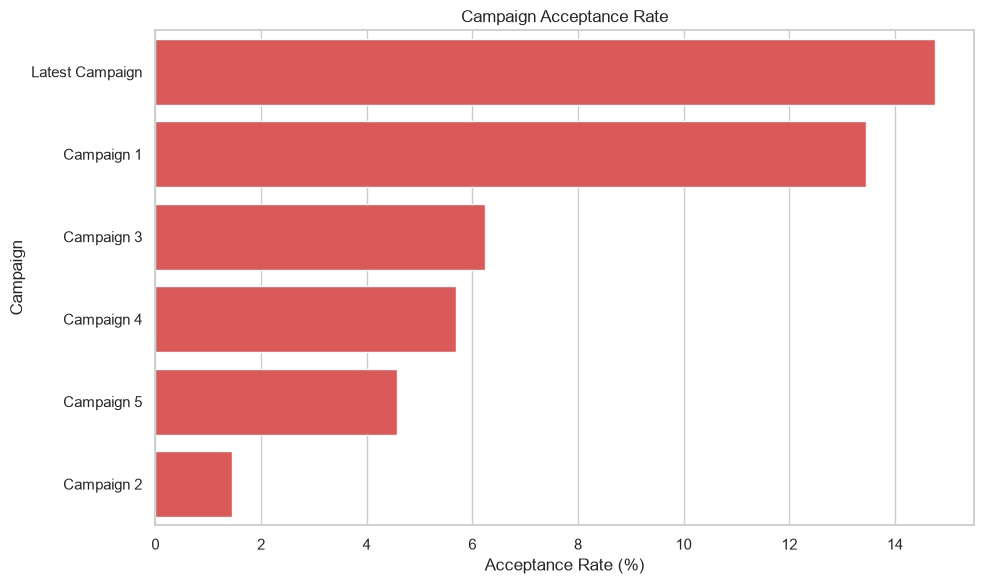

,Campaign,Acceptance_Rate
5,Latest Campaign,14.76
0,Campaign 1,13.44
2,Campaign 3,6.24
3,Campaign 4,5.68
4,Campaign 5,4.57
1,Campaign 2,1.44


In [39]:
campaign_columns = [
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
    "AcceptedCmp4", "AcceptedCmp5", "Response"
]
campaign_labels = {
    "AcceptedCmp1": "Campaign 1", "AcceptedCmp2": "Campaign 2",
    "AcceptedCmp3": "Campaign 3", "AcceptedCmp4": "Campaign 4",
    "AcceptedCmp5": "Campaign 5", "Response": "Latest Campaign"
}

campaign_summary = (cleaned_df[campaign_columns].mean() * 100).reset_index()
campaign_summary.columns = ["Campaign", "Acceptance_Rate"]
campaign_summary["Campaign"] = campaign_summary["Campaign"].map(campaign_labels)
campaign_summary = campaign_summary.sort_values("Acceptance_Rate", ascending=False)

sns.barplot(data=campaign_summary, x="Acceptance_Rate", y="Campaign", color="#EF4444")
plt.title("Campaign Acceptance Rate")
plt.xlabel("Acceptance Rate (%)")
plt.tight_layout()
plt.show()

campaign_summary


## 6.9 Latest Campaign Response by Age and Income Band

### Business Question
Which age and income groups respond most strongly to the latest campaign?

### Reason for the Visual
Grouped category comparisons reveal demographic response differences.


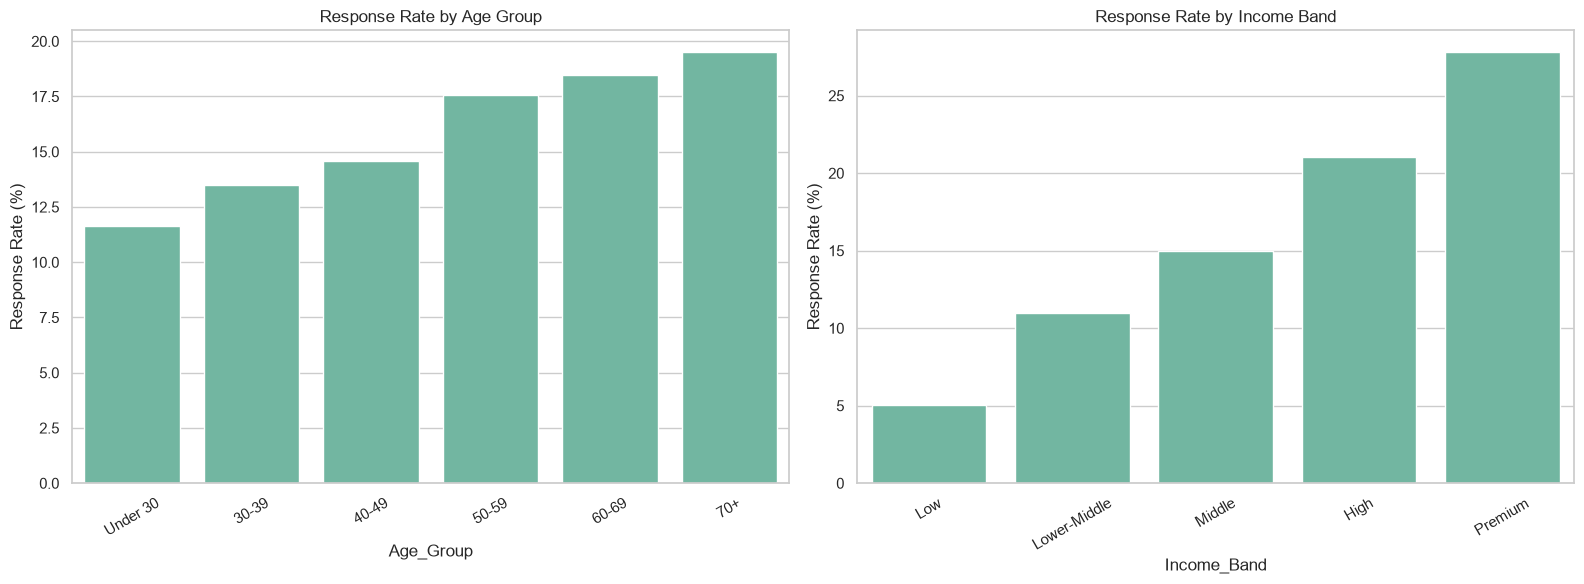

In [40]:
age_response = cleaned_df.groupby("Age_Group", observed=True)["Response"].mean().mul(100).reset_index()
income_response = cleaned_df.groupby("Income_Band", observed=True)["Response"].mean().mul(100).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=age_response, x="Age_Group", y="Response", ax=axes[0])
axes[0].set_title("Response Rate by Age Group")
axes[0].set_ylabel("Response Rate (%)")
axes[0].tick_params(axis="x", rotation=30)
sns.barplot(data=income_response, x="Income_Band", y="Response", ax=axes[1])
axes[1].set_title("Response Rate by Income Band")
axes[1].set_ylabel("Response Rate (%)")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## 6.10 Income, Spending and Campaign Response

### Business Question
Does the relationship between income and spending differ between responders and non-responders?

### Reason for the Visual
A scatter plot shows the relationship between two continuous measures while colour separates response groups.


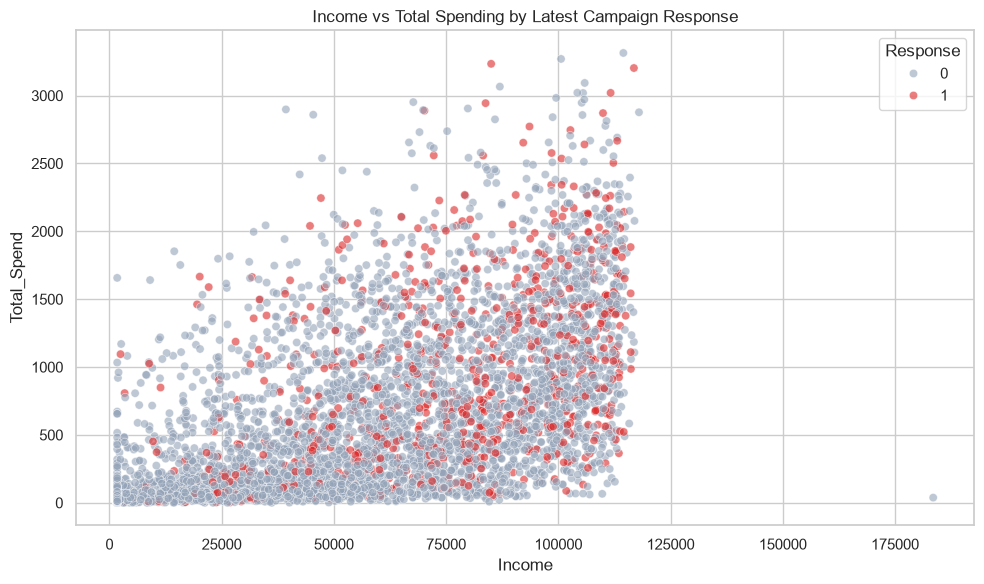

In [41]:
plot_sample = cleaned_df.sample(min(5000, len(cleaned_df)), random_state=42)

sns.scatterplot(
    data=plot_sample, x="Income", y="Total_Spend",
    hue="Response", alpha=0.6, palette={0: "#94A3B8", 1: "#DC2626"}
)
plt.title("Income vs Total Spending by Latest Campaign Response")
plt.tight_layout()
plt.show()


## 6.11 Correlation Analysis

### Business Question
Which numerical customer behaviours move together?

### Reason for the Visual
A correlation heatmap summarises the direction and strength of multiple pairwise relationships.


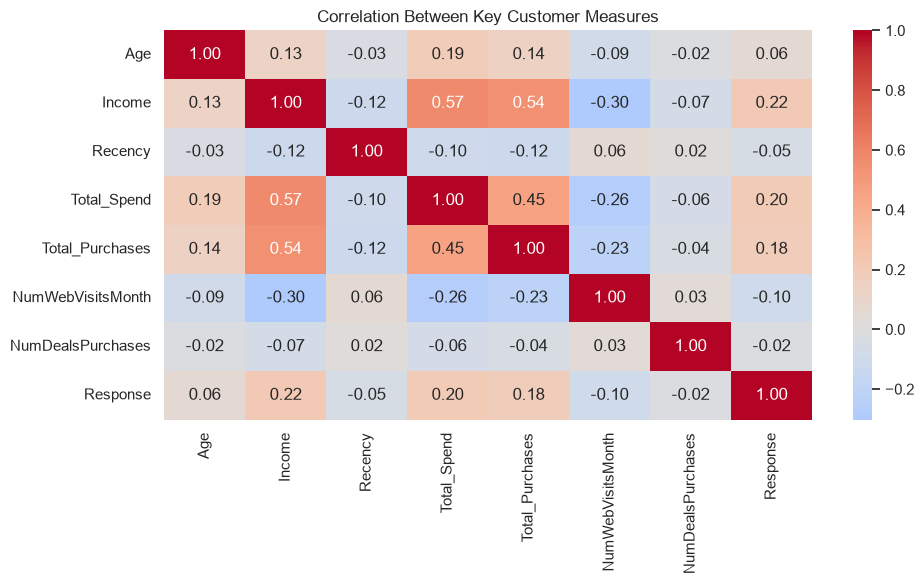

In [42]:
correlation_columns = [
    "Age", "Income", "Recency", "Total_Spend", "Total_Purchases",
    "NumWebVisitsMonth", "NumDealsPurchases", "Response"
]

correlation_matrix = cleaned_df[correlation_columns].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Key Customer Measures")
plt.tight_layout()
plt.show()


### EDA Interpretation Framework

For the final report, document each important result using this structure:

1. **Observation:** State the measured pattern using values from the output.
2. **Business Insight:** Explain why the pattern matters commercially.
3. **Recommendation:** Propose a specific management action supported by the finding.


# Step 7: Rule-Based Customer Segmentation

## Objective

Create transparent segments using GUVI-required business rules and additional customer-value rules. Rule-based segments are easy for management to understand and implement.


## 7.1 Create Required and Strategic Segment Flags


In [43]:
high_spender_threshold = cleaned_df["Total_Spend"].quantile(0.90)
frequent_purchase_threshold = cleaned_df["Total_Purchases"].quantile(0.75)
deal_threshold = cleaned_df["NumDealsPurchases"].quantile(0.75)

cleaned_df["High_Income_Customer"] = (cleaned_df["Income"] > 75000).astype(int)
cleaned_df["Young_Customer"] = (cleaned_df["Age"] < 30).astype(int)
cleaned_df["Campaign_Responder"] = (cleaned_df["Response"] == 1).astype(int)
cleaned_df["High_Web_Engagement"] = (cleaned_df["NumWebVisitsMonth"] > 5).astype(int)
cleaned_df["Family_Customer"] = (cleaned_df["Total_Children"] > 0).astype(int)
cleaned_df["High_Spender"] = (cleaned_df["Total_Spend"] >= high_spender_threshold).astype(int)

cleaned_df["Loyal_Customer"] = (
    (cleaned_df["Total_Purchases"] >= frequent_purchase_threshold)
    & (cleaned_df["Recency"] <= 30)
).astype(int)

cleaned_df["Deal_Hunter"] = (
    cleaned_df["NumDealsPurchases"] >= deal_threshold
).astype(int)

cleaned_df["Under_Served_Customer"] = (
    (cleaned_df["NumWebVisitsMonth"] > 5)
    & (cleaned_df["Total_Spend"] < spend_median)
    & (cleaned_df["Response"] == 0)
).astype(int)

cleaned_df["Ideal_Target_Customer"] = (
    (cleaned_df["High_Spender"] == 1)
    & (cleaned_df["Total_Purchases"] >= purchase_median)
    & (cleaned_df["Complain"] == 0)
).astype(int)

print("Segment flags created successfully.")


Segment flags created successfully.


## 7.2 Segment Rule Dictionary


In [44]:
segment_rules = pd.DataFrame({
    "Segment": [
        "High Income Customer", "Young Customer", "Campaign Responder",
        "High Web Engagement", "Family Customer", "High Spender",
        "Loyal Customer", "Deal Hunter", "Under-served Customer",
        "Ideal Target Customer"
    ],
    "Rule": [
        "Income > 75,000", "Age < 30", "Latest campaign Response = 1",
        "Monthly web visits > 5", "Total children > 0",
        "Total spend at or above 90th percentile",
        "Purchases at or above 75th percentile and Recency <= 30",
        "Deal purchases at or above 75th percentile",
        "High web visits, below-median spending and no latest response",
        "High spender, at least median purchases and no complaint"
    ]
})

segment_rules


,Segment,Rule
0,High Income Customer,"Income > 75,000"
1,Young Customer,Age < 30
2,Campaign Responder,Latest campaign Response = 1
3,High Web Engagement,Monthly web visits > 5
4,Family Customer,Total children > 0
5,High Spender,Total spend at or above 90th percentile
6,Loyal Customer,Purchases at or above 75th percentile and Rece...
7,Deal Hunter,Deal purchases at or above 75th percentile
8,Under-served Customer,"High web visits, below-median spending and no ..."
9,Ideal Target Customer,"High spender, at least median purchases and no..."


## 7.3 Segment Performance Summary


In [45]:
segment_columns = {
    "High Income Customer": "High_Income_Customer",
    "Young Customer": "Young_Customer",
    "Campaign Responder": "Campaign_Responder",
    "High Web Engagement": "High_Web_Engagement",
    "Family Customer": "Family_Customer",
    "High Spender": "High_Spender",
    "Loyal Customer": "Loyal_Customer",
    "Deal Hunter": "Deal_Hunter",
    "Under-served Customer": "Under_Served_Customer",
    "Ideal Target Customer": "Ideal_Target_Customer"
}

segment_records = []
for segment_name, flag_column in segment_columns.items():
    segment_data = cleaned_df[cleaned_df[flag_column] == 1]
    segment_records.append({
        "Segment": segment_name,
        "Customers": segment_data["ID"].nunique(),
        "Customer_Share": len(segment_data) / len(cleaned_df),
        "Average_Income": segment_data["Income"].mean(),
        "Average_Spend": segment_data["Total_Spend"].mean(),
        "Response_Rate": segment_data["Response"].mean()
    })

segment_summary = pd.DataFrame(segment_records).sort_values(
    "Response_Rate", ascending=False
)
segment_summary


,Segment,Customers,Customer_Share,Average_Income,Average_Spend,Response_Rate
2,Campaign Responder,8265,0.15,"75,317.24",939.29,1.00
9,Ideal Target Customer,4504,0.08,"90,080.20","1,984.29",0.27
5,High Spender,5608,0.10,"87,839.91","1,971.55",0.26
6,Loyal Customer,3677,0.07,"79,003.48","1,005.95",0.24
0,High Income Customer,19782,0.35,"94,997.93","1,038.03",0.24
7,Deal Hunter,21776,0.39,"55,734.26",613.58,0.14
3,High Web Engagement,29970,0.54,"48,626.72",510.08,0.12
1,Young Customer,8285,0.15,"51,779.08",485.58,0.12
4,Family Customer,38222,0.68,"48,493.55",499.70,0.12
8,Under-served Customer,16765,0.30,"32,309.42",129.78,0.00


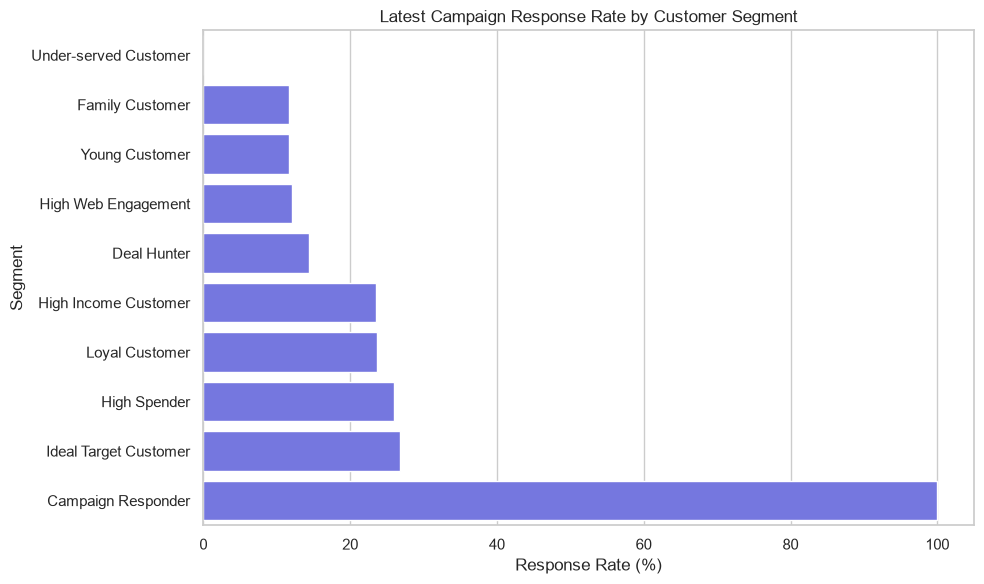

In [46]:
plot_segments = segment_summary.copy()
plot_segments["Response_Rate_Percent"] = plot_segments["Response_Rate"] * 100

sns.barplot(
    data=plot_segments.sort_values("Response_Rate_Percent"),
    x="Response_Rate_Percent", y="Segment", color="#6366F1"
)
plt.title("Latest Campaign Response Rate by Customer Segment")
plt.xlabel("Response Rate (%)")
plt.tight_layout()
plt.show()


# Step 8: Target Customer and Campaign Analysis

## Objective

Profile ideal targets, under-served customers and high-value customers so management can select the right audience, offer and communication channel.


## 8.1 Ideal Target Customer Profile


In [47]:
ideal_targets = cleaned_df[cleaned_df["Ideal_Target_Customer"] == 1]

ideal_target_profile = pd.DataFrame({
    "Metric": [
        "Customers", "Average Age", "Average Income", "Average Spend",
        "Average Purchases", "Response Rate", "Most Common Country",
        "Most Common Preferred Channel"
    ],
    "Value": [
        ideal_targets["ID"].nunique(),
        ideal_targets["Age"].mean(),
        ideal_targets["Income"].mean(),
        ideal_targets["Total_Spend"].mean(),
        ideal_targets["Total_Purchases"].mean(),
        ideal_targets["Response"].mean(),
        ideal_targets["Country"].mode().iloc[0] if not ideal_targets.empty else "N/A",
        ideal_targets["Preferred_Channel"].mode().iloc[0] if not ideal_targets.empty else "N/A"
    ]
})

ideal_target_profile


,Metric,Value
0,Customers,4504
1,Average Age,46.65
2,Average Income,"90,080.20"
3,Average Spend,"1,984.29"
4,Average Purchases,16.53
5,Response Rate,0.27
6,Most Common Country,Spain
7,Most Common Preferred Channel,Store


## 8.2 Under-Served Customer Profile


In [48]:
under_served = cleaned_df[cleaned_df["Under_Served_Customer"] == 1]

under_served_summary = under_served.groupby(
    ["Age_Group", "Income_Band"], observed=True
).agg(
    Customers=("ID", "nunique"),
    Average_Web_Visits=("NumWebVisitsMonth", "mean"),
    Average_Spend=("Total_Spend", "mean"),
    Average_Purchases=("Total_Purchases", "mean")
).reset_index().sort_values("Customers", ascending=False)

under_served_summary.head(10)


,Age_Group,Income_Band,Customers,Average_Web_Visits,Average_Spend,Average_Purchases
5,30-39,Low,3154,7.27,77.95,6.08
10,40-49,Low,2532,7.24,87.65,6.21
0,Under 30,Low,1807,7.29,69.18,5.94
15,50-59,Low,1093,7.22,98.18,6.70
6,30-39,Lower-Middle,1080,7.26,141.61,8.60
7,30-39,Middle,914,7.18,189.33,9.98
11,40-49,Lower-Middle,862,7.22,159.70,8.74
12,40-49,Middle,798,7.19,197.06,9.91
1,Under 30,Lower-Middle,609,7.24,133.02,8.14
2,Under 30,Middle,493,7.32,168.20,9.69


## 8.3 High-Value Customer Channel Behaviour


In [49]:
high_value_customers = cleaned_df[
    cleaned_df["Customer_Value_Segment"] == "Premium Value"
]

high_value_channel_summary = pd.DataFrame({
    "Channel": ["Web", "Catalog", "Store", "Deals", "Web Visits"],
    "Average_Activity": [
        high_value_customers["NumWebPurchases"].mean(),
        high_value_customers["NumCatalogPurchases"].mean(),
        high_value_customers["NumStorePurchases"].mean(),
        high_value_customers["NumDealsPurchases"].mean(),
        high_value_customers["NumWebVisitsMonth"].mean()
    ]
}).sort_values("Average_Activity", ascending=False)

high_value_channel_summary


,Channel,Average_Activity
2,Store,7.76
0,Web,6.87
1,Catalog,4.29
4,Web Visits,3.90
3,Deals,1.93


## 8.4 Campaign Response by Customer Value


In [50]:
value_campaign_summary = cleaned_df.groupby(
    "Customer_Value_Segment", observed=True
).agg(
    Customers=("ID", "nunique"),
    Average_Spend=("Total_Spend", "mean"),
    Latest_Response_Rate=("Response", "mean"),
    Average_Accepted_Campaigns=("Total_Accepted_Campaigns", "mean")
).reset_index().sort_values("Latest_Response_Rate", ascending=False)

value_campaign_summary


,Customer_Value_Segment,Customers,Average_Spend,Latest_Response_Rate,Average_Accepted_Campaigns
1,Premium Value,2832,"1,996.66",0.28,0.81
0,Growth Value,25168,"1,031.91",0.21,0.63
2,Standard Value,28000,151.19,0.08,0.28


# Step 9: Business Insights and Recommendations

## Objective

Translate analytical results into concise management findings and actions. The generated values below should also be referenced in the final report and Power BI recommendation page.


In [51]:
overall_response_rate = cleaned_df["Response"].mean() * 100
top_campaign = campaign_summary.iloc[0]
top_product = product_summary.sort_values("Total_Spending", ascending=False).iloc[0]
top_channel = channel_summary.sort_values("Total_Purchases", ascending=False).iloc[0]
top_country = country_summary.sort_values("Response_Rate", ascending=False).iloc[0]
top_segment = segment_summary[
    segment_summary["Segment"] != "Campaign Responder"
].iloc[0]

print(f"Overall latest campaign response rate: {overall_response_rate:.2f}%")
print(f"Best-performing campaign: {top_campaign['Campaign']} ({top_campaign['Acceptance_Rate']:.2f}%)")
print(f"Highest-spending product: {top_product['Product']} ({top_product['Total_Spending']:,.0f})")
print(f"Most-used purchase channel: {top_channel['Channel']} ({top_channel['Total_Purchases']:,.0f} purchases)")
print(f"Highest-response country: {top_country['Country']} ({top_country['Response_Rate']:.2f}%)")
print(f"Highest-response segment: {top_segment['Segment']} ({top_segment['Response_Rate'] * 100:.2f}%)")


Overall latest campaign response rate: 14.76%
Best-performing campaign: Latest Campaign (14.76%)
Highest-spending product: Meat (15,024,465)
Most-used purchase channel: Store (263,559 purchases)
Highest-response country: Australia (20.19%)
Highest-response segment: Ideal Target Customer (26.73%)


## Recommended Management Actions

1. **Prioritise proven high-value audiences:** Direct premium offers toward high spenders and ideal target customers using their preferred purchase channels.
2. **Improve campaign personalisation:** Use age group, income band, family status and product preference to create targeted messages instead of one generic campaign.
3. **Re-engage under-served visitors:** Test lower-cost web retargeting for customers with frequent website visits but below-median spending and no recent response.
4. **Optimise channel investment:** Increase resources for the purchase channel most used by high-value customers while testing improvements for weaker channels.
5. **Align offers with product demand:** Promote the highest-spending product category to proven buyers and test bundles with complementary lower-spending categories.
6. **Protect customer experience:** Exclude recent complainants from aggressive premium campaigns until their service issue has been addressed.
7. **Use controlled experiments:** Validate every targeting strategy with A/B tests and monitor response rate, incremental revenue, cost per response and customer retention.

### Important Limitation

The dataset does not contain campaign cost, profit margin, transaction dates or customer churn labels. Therefore, true ROI, profitability, lifetime value and churn cannot be calculated reliably. These should be added in future data collection.


# Step 10: Export Power BI and MySQL-Ready Data

## Objective

Export the final customer table and three long-format analytical tables. The customer CSV will be loaded into MySQL. All four files can be imported into Power BI for a clean and flexible data model.


## 10.1 Prepare the Final Customer Table


In [52]:
final_df = cleaned_df.copy()

category_columns_to_text = ["Age_Group", "Income_Band"]
for column in category_columns_to_text:
    final_df[column] = final_df[column].astype("string")

final_df["Dt_Customer"] = final_df["Dt_Customer"].dt.strftime("%Y-%m-%d")

print("Final customer table shape:", final_df.shape)
final_df.head()


Final customer table shape: (56000, 58)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Education_Group,Relationship_Status,Income_Outlier_Flag,Age,Customer_Tenure_Days,Customer_Tenure_Months,Total_Children,Has_Children,Total_Spend,Total_Purchases,Preferred_Channel,Historical_Accepted_Campaigns,Total_Accepted_Campaigns,Campaign_Acceptance_Rate,Age_Group,Income_Band,Relationship_Group,Spending_Segment,Purchase_Frequency,Customer_Value_Segment,High_Income_Customer,Young_Customer,Campaign_Responder,High_Web_Engagement,Family_Customer,High_Spender,Loyal_Customer,Deal_Hunter,Under_Served_Customer,Ideal_Target_Customer
0,342199,1985,Graduation,Together,"59,011.70",1,0,2012-11-17,3,0,2,45,6,0,16,3,2,5,3,4,0,0,0,0,0,0,0,Spain,Graduation,Together,Normal,29,590,19.40,1,Yes,69,10,Catalog,0,0,0.00,Under 30,Middle,Partnered,Low Spender,Occasional,Standard Value,0,1,0,0,1,0,0,1,0,0
1,8075450,1975,Master,Single,"1,730.00",1,1,2013-04-10,96,0,0,19,1,19,0,1,1,0,2,3,0,0,0,0,0,0,0,Spain,Master,Single,Normal,39,446,14.70,2,Yes,39,3,Store,0,0,0.00,30-39,Low,Not Partnered,Low Spender,Occasional,Standard Value,0,0,0,0,1,0,0,0,0,0
2,13664263,1978,Graduation,Married,"98,584.60",0,0,2014-01-11,99,920,0,339,0,115,138,3,2,1,6,3,0,0,0,0,0,0,0,Australia,Graduation,Married,Normal,36,170,5.60,0,No,1512,9,Store,0,0,0.00,30-39,High,Partnered,Medium Spender,Occasional,Growth Value,1,0,0,0,0,0,0,1,0,0
3,16164787,1976,Graduation,Married,"74,031.50",1,0,2014-06-18,47,265,0,130,7,1,75,1,4,0,11,4,0,0,0,0,0,0,0,Spain,Graduation,Married,Normal,38,12,0.40,1,Yes,478,15,Store,0,0,0.00,30-39,Middle,Partnered,Medium Spender,Frequent,Growth Value,0,0,0,0,1,0,0,0,0,0
4,15815139,1981,Graduation,Divorced,"52,784.20",1,1,2014-05-20,0,30,3,55,242,0,0,1,3,2,3,6,0,0,0,0,0,0,0,Canada,Graduation,Divorced,Normal,33,41,1.30,2,Yes,330,8,Web,0,0,0.00,30-39,Middle,Not Partnered,Low Spender,Occasional,Standard Value,0,0,0,1,1,0,0,0,1,0


## 10.2 Create Long-Format Campaign Table


In [53]:
campaign_table = final_df[["ID"] + campaign_columns].melt(
    id_vars="ID", var_name="Campaign", value_name="Accepted"
)
campaign_table["Campaign"] = campaign_table["Campaign"].map(campaign_labels)

campaign_table.head()


,ID,Campaign,Accepted
0,342199,Campaign 1,0
1,8075450,Campaign 1,0
2,13664263,Campaign 1,0
3,16164787,Campaign 1,0
4,15815139,Campaign 1,0


## 10.3 Create Long-Format Product Table


In [54]:
product_name_mapping = {
    "MntWines": "Wine", "MntFruits": "Fruits", "MntMeatProducts": "Meat",
    "MntFishProducts": "Fish", "MntSweetProducts": "Sweets", "MntGoldProds": "Gold"
}

product_table = final_df[["ID"] + product_columns].melt(
    id_vars="ID", var_name="Product", value_name="Amount_Spent"
)
product_table["Product"] = product_table["Product"].map(product_name_mapping)

product_table.head()


,ID,Product,Amount_Spent
0,342199,Wine,0
1,8075450,Wine,0
2,13664263,Wine,920
3,16164787,Wine,265
4,15815139,Wine,30


## 10.4 Create Long-Format Channel Table


In [55]:
channel_table = final_df[["ID"] + channel_columns].melt(
    id_vars="ID", var_name="Channel", value_name="Purchases"
)
channel_table["Channel"] = channel_table["Channel"].map(channel_name_mapping)

channel_table.head()


,ID,Channel,Purchases
0,342199,Web,2
1,8075450,Web,1
2,13664263,Web,2
3,16164787,Web,4
4,15815139,Web,3


## 10.5 Export the Final Files


In [56]:
output_files = {
    "Customer Data": dataset_folder / "marketing_campaign_cleaned.csv",
    "Campaign Table": dataset_folder / "powerbi_campaign_performance.csv",
    "Product Table": dataset_folder / "powerbi_product_spending.csv",
    "Channel Table": dataset_folder / "powerbi_channel_purchases.csv",
    "Segment Summary": dataset_folder / "powerbi_segment_summary.csv"
}

final_df.to_csv(output_files["Customer Data"], index=False)
campaign_table.to_csv(output_files["Campaign Table"], index=False)
product_table.to_csv(output_files["Product Table"], index=False)
channel_table.to_csv(output_files["Channel Table"], index=False)
segment_summary.to_csv(output_files["Segment Summary"], index=False)

for file_name, file_path in output_files.items():
    print(f"{file_name}: {file_path.name} | Created: {file_path.exists()}")


Customer Data: marketing_campaign_cleaned.csv | Created: True
Campaign Table: powerbi_campaign_performance.csv | Created: True
Product Table: powerbi_product_spending.csv | Created: True
Channel Table: powerbi_channel_purchases.csv | Created: True
Segment Summary: powerbi_segment_summary.csv | Created: True


## 10.6 Final Validation


In [57]:
final_validation = pd.DataFrame({
    "Check": [
        "Final Customer Rows", "Unique Customer IDs", "Duplicate IDs",
        "Missing Values", "Campaign Table Rows", "Product Table Rows",
        "Channel Table Rows"
    ],
    "Result": [
        len(final_df), final_df["ID"].nunique(), final_df["ID"].duplicated().sum(),
        final_df.isna().sum().sum(), len(campaign_table), len(product_table),
        len(channel_table)
    ]
})

final_validation


,Check,Result
0,Final Customer Rows,56000
1,Unique Customer IDs,56000
2,Duplicate IDs,0
3,Missing Values,0
4,Campaign Table Rows,336000
5,Product Table Rows,336000
6,Channel Table Rows,168000


# Notebook Conclusion

The notebook completed the Python portion of the Marketing Campaign Analysis project:

- Data understanding and quality assessment
- Professional cleaning with raw-data preservation
- Business-focused feature engineering
- Univariate, bivariate and multivariate EDA
- Rule-based and strategic segmentation
- Ideal-target and under-served customer profiling
- Evidence-led business recommendations
- MySQL-ready and Power BI-ready exports

The next project stages are to load `marketing_campaign_cleaned.csv` into MySQL, execute analytical SQL scripts and build the interactive Power BI dashboard.
